<a href="https://colab.research.google.com/github/aahan-charak24/Deep-Learning-Mastery/blob/main/Codes/Explicit_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3>Explicit Regularization is something that we can control unlike implicit where we let the training method push the model towards the best hyperparameters by itself </h3>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [12]:
df = pd.read_csv('ionosphere.csv', header = None)
df.head(3)

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g


In [13]:
dataframe = df.values
X = dataframe[:, 0:34].astype(float)
Y = dataframe[:, 34]

In [14]:
encoder = LabelEncoder()
encoder.fit(Y)
Y = encoder.transform(Y)
Y[:3]

array([1, 0, 1])

In [15]:
#convert to tensor
X = torch.tensor(X, dtype = torch.float32)
Y = torch.tensor(Y, dtype = torch.float32).reshape(-1, 1)


In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size = 0.7, shuffle = True)

<h1>L2 Regularization/Ridge Regression/Frobenius Norm Regularization </h1>

In [38]:
model = nn.Sequential(
    nn.Linear(34, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

In [44]:
def calc_l2(model):
  l2_lambda = 0.001
  l2_reg = torch.tensor(0.)

  for param in model.parameters():
    l2_reg += torch.norm(param, p=2)**2

  return l2_reg, l2_lambda


In [45]:
n_epochs = 50
lr = 0.1
loss_fn = nn.BCELoss()
optimizer = optim.SGD(model.parameters(),  lr = lr)
batch_size = 15
loss_arr = []


for epoch in range(n_epochs):
  batch_loss = 0
  for i in range(0, len(X_train), batch_size):
    X_batch = X_train[i:i+batch_size]
    Y_batch = Y_train[i:i+batch_size]

    #forward pass
    Y_pred = model(X_batch)

    #get the loss
    l2_reg, l2_lambda = calc_l2(model)
    loss = loss_fn(Y_pred, Y_batch) + l2_lambda * l2_reg

    #now calculate gradients
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    batch_loss += loss.item()

  #epoch end
  loss_arr.append(batch_loss/batch_size)

  print(f"Epoch: {epoch + 1} Loss: {batch_loss/batch_size}")








Epoch: 1 Loss: 0.15774927735328675
Epoch: 2 Loss: 0.14853805055220923
Epoch: 3 Loss: 0.14098390887180964
Epoch: 4 Loss: 0.1349284455180168
Epoch: 5 Loss: 0.12961910367012025
Epoch: 6 Loss: 0.12528313075502714
Epoch: 7 Loss: 0.12167374168833096
Epoch: 8 Loss: 0.11779270172119141
Epoch: 9 Loss: 0.11448815315961838
Epoch: 10 Loss: 0.11217795585592588
Epoch: 11 Loss: 0.10967242593566577
Epoch: 12 Loss: 0.10729805479447047
Epoch: 13 Loss: 0.10528329014778137
Epoch: 14 Loss: 0.10324221576253573
Epoch: 15 Loss: 0.10152462969223658
Epoch: 16 Loss: 0.09980876967310906
Epoch: 17 Loss: 0.09867271507779757
Epoch: 18 Loss: 0.09703605448206266
Epoch: 19 Loss: 0.09583528339862823
Epoch: 20 Loss: 0.094667249917984
Epoch: 21 Loss: 0.09341644297043482
Epoch: 22 Loss: 0.09258157387375832
Epoch: 23 Loss: 0.09161868020892143
Epoch: 24 Loss: 0.09066968411207199
Epoch: 25 Loss: 0.09000389799475669
Epoch: 26 Loss: 0.08911079838871956
Epoch: 27 Loss: 0.0882772758603096
Epoch: 28 Loss: 0.0877441848317782
Epoch:

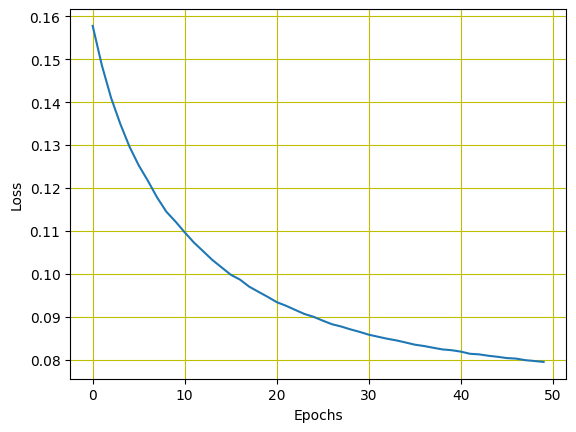

In [46]:
plt.plot(loss_arr)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid('True', color = 'y')
plt.show()

In [47]:
model.eval()

y_pred = model(X_test)

acc = (y_pred.round() == Y_test).float().mean()

print(f"Accuracy: {acc}")

Accuracy: 0.9716981053352356


<h2>Now we outperform even learning rate scheduler </h2>
